# Attitude Types in Original German TED Talks — Adjective Analysis

This notebook explores how **Attitude types** (Appreciation, Judgement, Affect) are expressed
through six adjectives in the original German TED talks corpus:

**gut, wichtig, glücklich, richtig, falsch, schlecht**

Each adjective was manually annotated by Bianca for:
- `DE_Evaluative?` — whether the adjective is used evaluatively or not
- `DE_Attitude_type` — the Attitude type it expresses (Appreciation / Judgement / Affect)
- plus metadata such as `Gender` and `Domain`

### What this notebook does
1. Load and combine the 6 annotated adjective files + the talk metadata file
2. Preprocess the text categories (e.g. `gut`, `gut,`, `gut.` should all count as `gut`)
3. Clean the data: drop rows with `Uncertain` or missing (`N/A`) Attitude type
4. Evaluative vs. non-evaluative counts & percentages (total and per adjective)
5. Attitude type distribution (total and per adjective)
6. Attitude type distribution across **Gender** and **Domain**, with Chi-square tests
7. Extra analysis (negation effects, adjective-by-domain patterns)

The code is kept intentionally simple — mostly `pandas` counting, cross-tabs, and basic plots.
All charts show the count/percentage value directly above each bar, and legends are placed
outside the plot area so they never cover the bars.


## 0. Setup

Import the libraries we need. `scipy.stats.chi2_contingency` is used for the Chi-square
tests of independence. We also define one small helper, `label_bars`, used on every chart
so bar values are always printed above the bars instead of inside them.

In [61]:
import pandas as pd
import numpy as np
import glob
import re
import string
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (7, 4)

def label_bars(ax, fmt="%.0f"):
    """Print the value of each bar directly above it."""
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=8, padding=2)

def legend_outside(ax, title=""):
    """Place the legend outside the plot area (to the right) instead of on top of the bars."""
    ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)


## 1. Upload your files

Before running the next cell, upload the following files into the **same folder as this
notebook** (or change `DATA_DIR` below to point to wherever you keep them):

- The 6 annotated adjective files from Bianca, e.g. `falsch_orig_Bianca.xlsx`,
  `gut_orig_Bianca.xlsx`, `wichtig_orig_Bianca.xlsx`, `glücklich_orig_Bianca.xlsx`,
  `richtig_orig_Bianca.xlsx`, `schlecht_orig_Bianca.xlsx`
  (the exact file names don't matter — the code below identifies each file by the
  adjective it actually contains, not by its file name)
- The talk metadata file, e.g. `German_original_TED_talks_xlsx_-_Tabelle1.csv`
  (contains `Text_ID`, `Domain`, `Gender`, `Year`, etc. for every talk)

If you are working in Jupyter/Colab, use the file upload widget or drag the files into the
file browser panel first.

In [62]:
DATA_DIR = "."  # change this if your files are in a different folder

TARGET_ADJECTIVES = ["gut", "wichtig", "glücklich", "richtig", "falsch", "schlecht"]

xlsx_files = glob.glob(f"{DATA_DIR}/*.xlsx")
csv_files = glob.glob(f"{DATA_DIR}/*.csv")

print("Excel files found:", xlsx_files)
print("CSV files found:", csv_files)


Excel files found: ['./gut_orig_Bianca.xlsx', './richtig_orig_Bianca.xlsx', './wichtig_orig_Bianca.xlsx', './glücklich_orig_Bianca.xlsx', './falsch_orig_Bianca.xlsx', './schlecht_orig_Bianca.xlsx', './attitude_analysis_results.xlsx']
CSV files found: ['./German_original_TED_talks.xlsx - Tabelle1.csv']


## 2. Load and combine the 6 adjective files

We open every Excel file and check which adjective appears in its `adjective_lemma`
column, matching against a **cleaned** version of that column (see step 3 below) so that
stray punctuation (e.g. `gut.`, `gut,`) doesn't stop a file from being recognized. This is
more robust than guessing the adjective from the file name.

In [63]:
def clean_text(series):
    """Strip whitespace/punctuation and lowercase a text column."""
    return (
        series.astype(str)
        .str.strip()
        .str.strip(string.punctuation)
        .str.strip()
        .str.lower()
    )

adjective_dfs = {}

for path in xlsx_files:
    df_temp = pd.read_excel(path)
    if "adjective_lemma" not in df_temp.columns:
        continue
    found = clean_text(df_temp["adjective_lemma"].dropna()).unique()
    for adj in found:
        if adj in TARGET_ADJECTIVES:
            adjective_dfs[adj] = df_temp

print("Adjectives loaded:", list(adjective_dfs.keys()))
missing = [a for a in TARGET_ADJECTIVES if a not in adjective_dfs]
if missing:
    print("WARNING - still missing:", missing, "-> upload these files and re-run.")


Adjectives loaded: ['gut', 'richtig', 'wichtig', 'glücklich', 'falsch', 'schlecht']


In [64]:
# Combine all loaded adjective files into one long dataframe
df = pd.concat(adjective_dfs.values(), ignore_index=True)
print("Combined shape:", df.shape)
df.head()


Combined shape: (1228, 13)


,Domain,file,source_file,Gender,sentence_index,adjective_lemma,adjective_form,sentence_text,norm_text,text,DE_Evaluative?,DE_Attitude_type,negation
0,Art,Art_10_de.conllu,Art_10.txt,F,39,gut,gut,"weil es ist gut für eure ganze Haltung , es is...",und ich wurde euch ermutigen wann immer ihr di...,"Und ich würde euch ermutigen, wann immer ihr d...",Evaluative,Appreciation,not negated
1,Art,Art_10_de.conllu,Art_10.txt,F,39,gut,gut,"weil es ist gut für eure ganze Haltung , es is...",und ich wurde euch ermutigen wann immer ihr di...,"Und ich würde euch ermutigen, wann immer ihr d...",Evaluative,Appreciation,not negated
2,Art,Art_1_de.conllu,Art_1.txt,M,12,gut,gute,Und wenn sie gute reale Fakten haben .,und wenn sie gute reale fakten haben und die l...,Und wenn sie gute reale Fakten haben und die l...,Evaluative,Appreciation,not negated
3,Art,Art_1_de.conllu,Art_1.txt,M,14,gut,gute,"Jeder , der schon mal von der Boulevardpresse ...",jeder der schon mal von der boulevardpresse du...,"Jeder, der schon mal von der Boulevardpresse d...",Evaluative,Appreciation,not negated
4,Art,Art_1_de.conllu,Art_1.txt,M,31,gut,gut,Nehmen noch einen Drink. und noch einen Drink....,nehmen noch einen drink und noch einen drink u...,Nehmen noch einen Drink und noch einen Drink u...,Evaluative-not_speaker,Appreciation,not negated


##Total sentences: 1228

## 3. Load the talk metadata

We also load the metadata file with `Domain`, `Gender`, `Year`, etc. Note that the
adjective files already contain `Domain` and `Gender` columns copied over per sentence,
so for the main analyses below we can use those directly. The metadata file is mainly
used later for the extra analysis (e.g. by speaker language variety).

In [65]:
meta_path = csv_files[0]  # assumes one metadata CSV was uploaded
meta = pd.read_csv(meta_path)
print("Metadata shape:", meta.shape)
meta.head()


Metadata shape: (110, 11)


,Text_ID,Domain,Speaker,"Speaker language: German, Austrian, Swiss?",Gender,Year,Title,Subtopic,Video link,Status,Note for transcribers
0,Art_1,Art,Veit Etzold,German,M,2014,Die Kunst des Storytelling,"experiment with hotel bars, elements of a good...",https://youtu.be/xOTZfGyVh1I?si=OY0vSDS2o0U8925A,transcribed,Please only choose talks by 1 speaker; can you...
1,Art_2,Art,Philipp Schuch,German,M,2016,Design löst unbekannte Probleme,Seeing the world through the eyes of a designer,https://youtu.be/4H3OssZ1znE?si=dHz41FcqdKoU8aLO,transcribed,"For the videos that I marked as ""confirmed"" yo..."
2,Art_3,Art,Guido Kramann,German,M,2020,Komponieren für alle,"composing music, mathematics, tools",https://www.youtube.com/watch?v=Wv1_O-D4l9g&li...,transcribed,"Please save transcripts as .txt file, not as W..."
3,Art_4,Art,Jan Vogler,German,M,2018,Die Wirkung von Musik auf die Gesellschaft,"music, society, the impact of music",https://www.youtube.com/watch?v=WqaxIw0fL28&li...,transcribed,Please check all your videos collected by list...
4,Art_5,Art,Tobias Schirneck,German (dialect),M,2018,Rapping away your sorrows,"music, rap, social work",https://www.youtube.com/watch?v=tOBv42GJyx8&li...,transcribed,NaN


In [66]:
# Add a Text_ID column to the adjective data, derived from the 'file' column
# e.g. 'Art_1_de.conllu' -> 'Art_1', so we can merge in extra metadata (Year, language) later
df["Text_ID"] = df["file"].str.replace("_de.conllu", "", regex=False)

df = df.merge(
    meta[["Text_ID", "Year", "Speaker language: German, Austrian, Swiss?"]],
    on="Text_ID", how="left"
)
df.rename(columns={"Speaker language: German, Austrian, Swiss?": "Speaker_variety"}, inplace=True)
df.head()


,Domain,file,source_file,Gender,sentence_index,adjective_lemma,adjective_form,sentence_text,norm_text,text,DE_Evaluative?,DE_Attitude_type,negation,Text_ID,Year,Speaker_variety
0,Art,Art_10_de.conllu,Art_10.txt,F,39,gut,gut,"weil es ist gut für eure ganze Haltung , es is...",und ich wurde euch ermutigen wann immer ihr di...,"Und ich würde euch ermutigen, wann immer ihr d...",Evaluative,Appreciation,not negated,Art_10,2024,Austrian
1,Art,Art_10_de.conllu,Art_10.txt,F,39,gut,gut,"weil es ist gut für eure ganze Haltung , es is...",und ich wurde euch ermutigen wann immer ihr di...,"Und ich würde euch ermutigen, wann immer ihr d...",Evaluative,Appreciation,not negated,Art_10,2024,Austrian
2,Art,Art_1_de.conllu,Art_1.txt,M,12,gut,gute,Und wenn sie gute reale Fakten haben .,und wenn sie gute reale fakten haben und die l...,Und wenn sie gute reale Fakten haben und die l...,Evaluative,Appreciation,not negated,Art_1,2014,German
3,Art,Art_1_de.conllu,Art_1.txt,M,14,gut,gute,"Jeder , der schon mal von der Boulevardpresse ...",jeder der schon mal von der boulevardpresse du...,"Jeder, der schon mal von der Boulevardpresse d...",Evaluative,Appreciation,not negated,Art_1,2014,German
4,Art,Art_1_de.conllu,Art_1.txt,M,31,gut,gut,Nehmen noch einen Drink. und noch einen Drink....,nehmen noch einen drink und noch einen drink u...,Nehmen noch einen Drink und noch einen Drink u...,Evaluative-not_speaker,Appreciation,not negated,Art_1,2014,German


## 4. Preprocess text categories

A few text columns contain what should be the same category, but written slightly
differently — most importantly `adjective_lemma`, where e.g. `gut`, `gut,` and `gut.`
are really all just **gut** (the trailing punctuation got attached during extraction).
If left as-is, these would be counted as separate adjectives everywhere below.

We fix this by stripping whitespace/punctuation and lowercasing the relevant text
columns. We also correct one known typo in the speaker-variety metadata (`Geman` →
`German`).

In [67]:
print("adjective_lemma values BEFORE cleaning:")
print(sorted(df["adjective_lemma"].unique()))

text_columns = ["adjective_lemma", "Domain", "Gender", "negation", "DE_Evaluative?"]
for col in text_columns:
    df[col] = clean_text(df[col])

# DE_Attitude_type: clean but keep NaN as NaN (clean_text would turn NaN into the string 'nan')
df["DE_Attitude_type"] = df["DE_Attitude_type"].where(
    df["DE_Attitude_type"].isna(),
    clean_text(df["DE_Attitude_type"])
)

# Restore proper capitalization for readability in tables/plots
df["adjective_lemma"] = df["adjective_lemma"].str.strip()
df["Gender"] = df["Gender"].str.upper()
df["Domain"] = df["Domain"].str.title()
df["negation"] = df["negation"].str.replace("not negated", "not_negated", regex=False)
df["DE_Attitude_type"] = df["DE_Attitude_type"].str.title()
df["DE_Evaluative?"] = df["DE_Evaluative?"].replace({
    "evaluative": "Evaluative",
    "evaluative-not_speaker": "Evaluative-not_speaker",
    "non-evaluative": "Non-evaluative"
})

# Fix known typo in speaker variety metadata
df["Speaker_variety"] = df["Speaker_variety"].replace({"Geman": "German"})

print()
print("adjective_lemma values AFTER cleaning:")
print(sorted(df["adjective_lemma"].unique()))


adjective_lemma values BEFORE cleaning:
['falsch', 'glücklich', 'gut', 'gut,', 'gut.', 'richtig', 'schlecht', 'wichtig']

adjective_lemma values AFTER cleaning:
['falsch', 'glücklich', 'gut', 'richtig', 'schlecht', 'wichtig']


## 5. Clean up the data

`DE_Evaluative?` has three values in the raw annotation: `Evaluative`,
`Evaluative-not_speaker` (evaluative, but not the speaker's own evaluation), and
`Non-evaluative`. For the main evaluative-vs-non-evaluative comparison we collapse the
first two into one `Evaluative` category.

For the Attitude-type analyses, we **only keep the three real Attitude types**
(`Appreciation`, `Judgement`, `Affect`) and drop everything else — that includes rows
with a missing value (`N/A`) and rows annotated as `Uncertain`.

In [68]:
# Collapse into a simple binary evaluative variable
df["Evaluative_binary"] = df["DE_Evaluative?"].replace({
    "Evaluative-not_speaker": "Evaluative"
})


# Remove rows where Evaluative_binary is the string "nan"
df = df[df["Evaluative_binary"] != "nan"]
df = df[df["DE_Evaluative?"] != "nan"]

print(df["DE_Evaluative?"].value_counts(dropna=False))
print()
print(df["Evaluative_binary"].value_counts(dropna=False))


DE_Evaluative?
Evaluative                1011
Evaluative-not_speaker     127
Non-evaluative              78
Name: count, dtype: int64

Evaluative_binary
Evaluative        1138
Non-evaluative      78
Name: count, dtype: int64


In [69]:
VALID_ATTITUDE_TYPES = ["Appreciation", "Judgement", "Affect"]

print("Attitude type values before dropping Uncertain/N-A:")
print(df["DE_Attitude_type"].value_counts(dropna=False))

print("\nRows before dropping Uncertain/N-A:", len(df))
df_attitude = df[df["DE_Attitude_type"].isin(VALID_ATTITUDE_TYPES)].copy()
print("Rows after dropping Uncertain/N-A:", len(df_attitude))
print()
print(df_attitude["DE_Attitude_type"].value_counts())


Attitude type values before dropping Uncertain/N-A:
DE_Attitude_type
Appreciation    786
Judgement       265
Affect           86
NaN              78
Uncertain         1
Name: count, dtype: int64

Rows before dropping Uncertain/N-A: 1216
Rows after dropping Uncertain/N-A: 1137

DE_Attitude_type
Appreciation    786
Judgement       265
Affect           86
Name: count, dtype: int64


## 6. Evaluative vs. non-evaluative — overall

How much of the adjective use across all 6 adjectives is evaluative vs. non-evaluative?

Plot name: Evaluative vs. Non-evaluative (all adjectives)

                   count  percent
Evaluative_binary                
Evaluative          1138     93.6
Non-evaluative        78      6.4


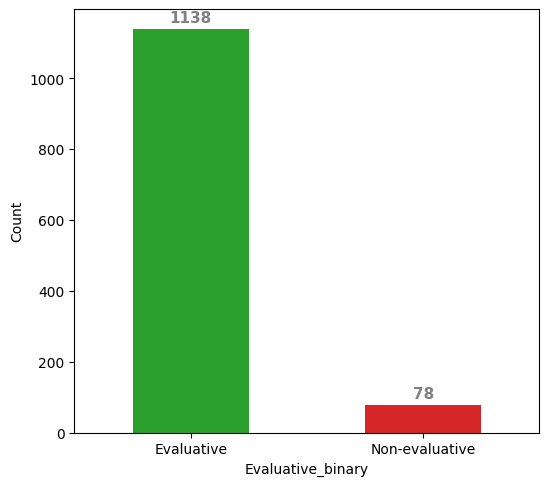

In [133]:
eval_counts = df["Evaluative_binary"].value_counts()
eval_pct = df["Evaluative_binary"].value_counts(normalize=True).mul(100).round(1)

summary = pd.DataFrame({
    "count": eval_counts,
    "percent": eval_pct
})

print(summary)
plt.figure(figsize=(6, 5.5))
# Reorder so Evaluative is first
summary = summary.loc[["Evaluative", "Non-evaluative"]]

ax = summary["count"].plot(
    kind="bar",
    color=["#2ca02c", "#d62728"]
)


# Show count labels
for container in ax.containers:
    ax.bar_label(
    ax.containers[0],
    fontsize=11,
    fontweight="bold",
    color="gray",
    padding=3
)

#plt.title("Evaluative vs. Non-evaluative (all adjectives)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Evaluative vs. non-evaluative — per adjective

Same comparison, broken down by adjective, so we can see whether some adjectives are
used more evaluatively than others.

## Plot: Evaluative vs. non-evaluative — per adjective

Counts:
Evaluative_binary  Evaluative  Non-evaluative
adjective_lemma                              
falsch                     71               1
glücklich                  30               2
gut                       573              71
richtig                   176               2
schlecht                   53               2
wichtig                   235               0

Row percentages:
Evaluative_binary  Evaluative  Non-evaluative
adjective_lemma                              
falsch                   98.6             1.4
glücklich                93.8             6.2
gut                      89.0            11.0
richtig                  98.9             1.1
schlecht                 96.4             3.6
wichtig                 100.0             0.0


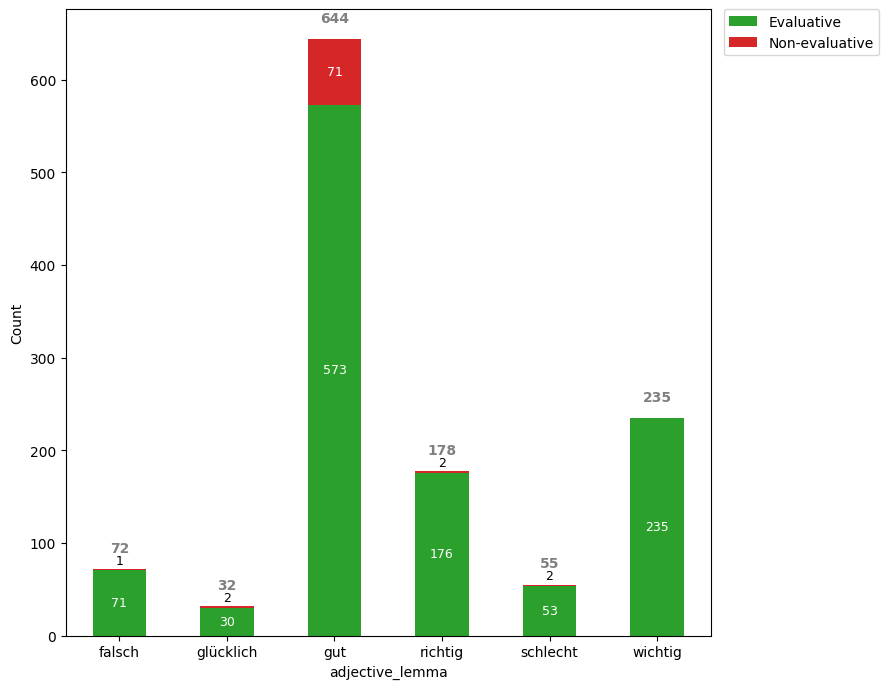

In [131]:
eval_by_adj = pd.crosstab(df["adjective_lemma"], df["Evaluative_binary"])
eval_by_adj_pct = pd.crosstab(df["adjective_lemma"], df["Evaluative_binary"], normalize="index").mul(100).round(1)

print("Counts:")
print(eval_by_adj)
print()
print("Row percentages:")
print(eval_by_adj_pct)


eval_by_adj = eval_by_adj[["Evaluative", "Non-evaluative"]]

ax = eval_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 7),
    color=["#2ca02c", "#d62728"],   # green, red
)
# Add count labels inside each segment
...
# Add count labels inside each segment
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if height == 0:
            continue

        x = bar.get_x() + bar.get_width()/2
        y = bar.get_y() + height/2

        if height < 10:
            ax.text(
                x,
                bar.get_y() + height + 2,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9
            )
        else:
            ax.text(
                x,
                y,
                f"{int(height)}",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )

# Total count above each stacked bar
totals = eval_by_adj.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 15,
        str(total),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="gray"
    )

legend_outside(ax)
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Attitude type distribution — overall

Among the evaluative uses, which Attitude type (Appreciation, Judgement, Affect) is most
common overall? (We use `df_attitude`, i.e. rows with one of the three real Attitude
types — `Uncertain`/missing rows have already been dropped.)

In [122]:
att_counts = df_attitude["DE_Attitude_type"].value_counts()
att_pct = df_attitude["DE_Attitude_type"].value_counts(normalize=True).mul(100).round(1)

summary_att = pd.DataFrame({"count": att_counts, "percent": att_pct})
print(summary_att)


                  count  percent
DE_Attitude_type                
Appreciation        786     69.1
Judgement           265     23.3
Affect               86      7.6


### Attitude type distribution — per adjective

This shows which Attitude type each individual adjective tends to express
(e.g. we'd expect `glücklich` to lean towards Affect, and `gut`/`schlecht` towards
Appreciation or Judgement, depending on context).

## Plot: Attitude type distribution (all adjectives)

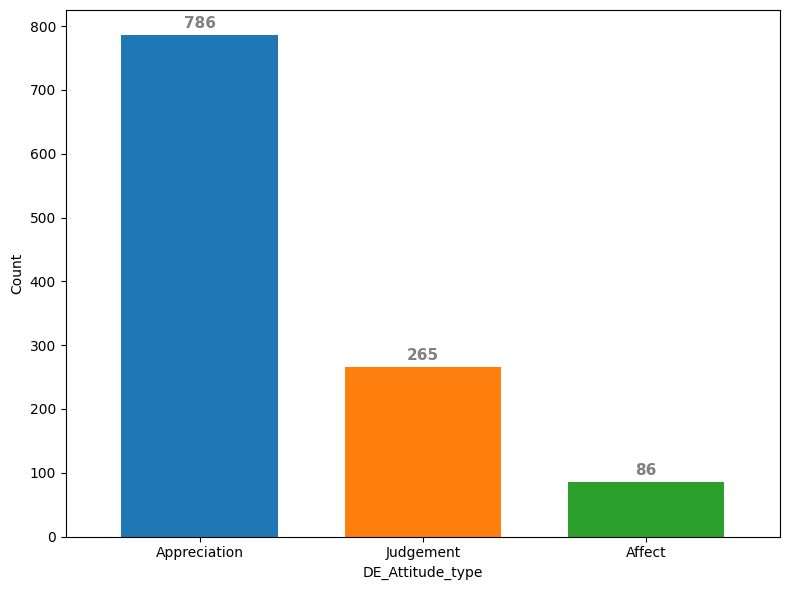

In [123]:
ax = att_counts.plot(
    kind="bar",
    color=["tab:blue", "tab:orange", "tab:green"],
    width=0.7,
    figsize=(8,6),
)

ax.bar_label(
    ax.containers[0],
    fontsize=11,
    fontweight="bold",
    color="gray",
    padding=3
)

#plt.title("Attitude type distribution (all adjectives)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Attitude type across Gender

Do male and female speakers differ in which Attitude type they express? We build a
cross-tabulation and run a Chi-square test of independence: a significant result
(p < .05) means the distribution of Attitude types is not independent of speaker gender.

In [74]:
att_by_gender = pd.crosstab(df_attitude["Gender"], df_attitude["DE_Attitude_type"])
att_by_gender_pct = pd.crosstab(df_attitude["Gender"], df_attitude["DE_Attitude_type"], normalize="index").mul(100).round(1)

print("Counts:")
print(att_by_gender)
print()
print("Row percentages:")
print(att_by_gender_pct)

chi2, p, dof, expected = chi2_contingency(att_by_gender)
print(f"\nChi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")
print("--> significant (p < .05)" if p < 0.05 else "--> not significant (p >= .05)")


Counts:
DE_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                     55           370        120
M                     31           416        145

Row percentages:
DE_Attitude_type  Affect  Appreciation  Judgement
Gender                                           
F                   10.1          67.9       22.0
M                    5.2          70.3       24.5

Chi2 = 9.82, df = 2, p = 0.0074
--> significant (p < .05)


## Plot: Attitude types by gender

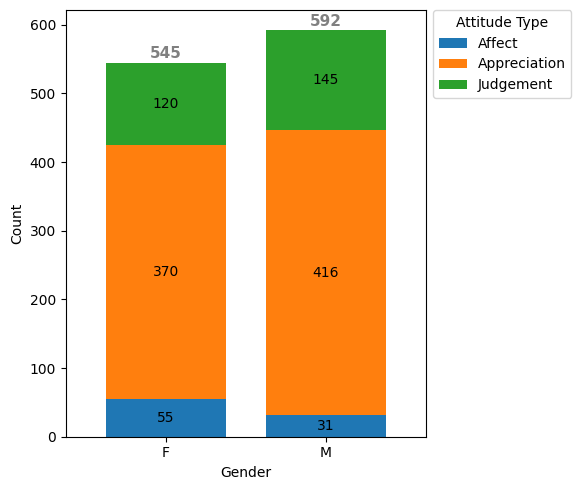

In [111]:
import matplotlib.pyplot as plt

# Counts table
att_by_gender = pd.crosstab(
    df_attitude["Gender"],
    df_attitude["DE_Attitude_type"]
)

# Reorder attitude types
order = ["Affect", "Appreciation", "Judgement"]
att_by_gender = att_by_gender.reindex(columns=order)

# Plot
ax = att_by_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(7,5),
    color=["tab:blue", "tab:orange", "tab:green"],
    width=0.75
)

# Labels inside each segment
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=10)

# Total labels on top
totals = att_by_gender.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 2,
        str(total),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color = "gray"
    )
#plt.title("Attitude types by gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.legend(
    title="Attitude Type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## 9. Attitude type across Domain

Same question for talk `Domain` (e.g. Art, Business, ...): does the topic domain of the
talk relate to which Attitude type speakers use? Note: with many domains and few
observations, some cells may be small — the Chi-square test result should be read with
that caveat in mind.

In [120]:
att_by_domain = pd.crosstab(df_attitude["Domain"], df_attitude["DE_Attitude_type"])
att_by_domain_pct = pd.crosstab(df_attitude["Domain"], df_attitude["DE_Attitude_type"], normalize="index").mul(100).round(1)

print("Counts:")
print(att_by_domain)
print()
print("Row percentages:")
print(att_by_domain_pct)

chi2, p, dof, expected = chi2_contingency(att_by_domain)
print(f"\nChi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")
print("--> significant (p < .05)" if p < 0.05 else "--> not significant (p >= .05)")

min_expected = expected.min()
print(f"Smallest expected cell count = {min_expected:.2f}",
      "(rule of thumb: Chi2 results are less reliable if this is below 5)")


Counts:
DE_Attitude_type  Affect  Appreciation  Judgement
Domain                                           
Art                    5            91         23
Business               4            75         47
Education              5            84         38
Entertainment         16            67         20
History                7            54         17
Medicine               9            74         27
Philosophy            22            80         28
Politics And Law       3            67         11
Psychology            10            65         28
Science                0            55         12
Technology             5            74         14

Row percentages:
DE_Attitude_type  Affect  Appreciation  Judgement
Domain                                           
Art                  4.2          76.5       19.3
Business             3.2          59.5       37.3
Education            3.9          66.1       29.9
Entertainment       15.5          65.0       19.4
History              9.0

##Plot :Attitude types across domains

<Figure size 2000x2000 with 0 Axes>

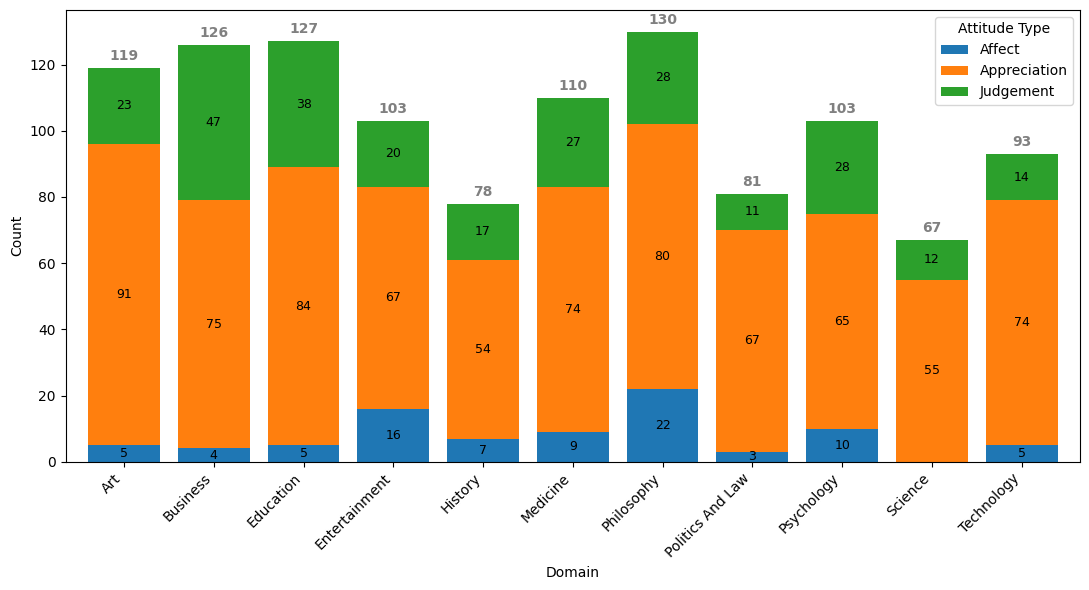

In [96]:
import matplotlib.pyplot as plt

# Counts table
att_by_domain = pd.crosstab(
    df_attitude["Domain"],
    df_attitude["DE_Attitude_type"]
)

# Reorder attitude types
order = ["Affect", "Appreciation", "Judgement"]
att_by_domain = att_by_domain.reindex(columns=order)

plt.figure(figsize=(20, 20))
# Plot
ax = att_by_domain.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["tab:blue", "tab:orange", "tab:green"],
    width=0.8
)

# Labels inside each segment
for container in ax.containers:
    labels = [f"{int(v)}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

# Total labels on top of each bar
totals = att_by_domain.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,                  # x-position
        total + 1.5,          # slightly above the bar
        str(total),         # label
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color = "gray"
    )

#plt.title("Attitude types across domains")
plt.xlabel("Domain")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Attitude Type")
plt.tight_layout()
plt.show()

## 10. Extra analysis

A few additional checks that build on the same data:

**10.1 Negation** — does negation (e.g. "nicht gut" vs. "gut") relate to whether the
adjective is used evaluatively, or which Attitude type it expresses?

**10.2 Evaluative use across Gender and Domain** — the sections above looked at Attitude
*type* only among evaluative uses; here we check whether the evaluative/non-evaluative
split itself differs by Gender or Domain (with Chi-square tests).

**10.3 Speaker variety** — using the metadata file, we check whether the German variety
spoken (German/Austrian/Swiss) relates to Attitude type — a nice example of using the
extra metadata columns we merged in earlier.

In [19]:
# 10.1 Negation vs. Evaluative use, and Negation vs. Attitude type
neg_vs_eval = pd.crosstab(df["negation"], df["Evaluative_binary"])
print("Negation vs. Evaluative use:")
print(neg_vs_eval)
chi2, p, dof, expected = chi2_contingency(neg_vs_eval)
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}\n")

neg_vs_att = pd.crosstab(df_attitude["negation"], df_attitude["DE_Attitude_type"])
print("Negation vs. Attitude type:")
print(neg_vs_att)
chi2, p, dof, expected = chi2_contingency(neg_vs_att)
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")


Negation vs. Evaluative use:
Evaluative_binary  Evaluative  Non-evaluative  nan
negation                                          
nan                         0              78   12
negated                   106               0    0
not_negated              1032               0    0
Chi2 = 1228.00, df = 4, p = 0.0000

Negation vs. Attitude type:
DE_Attitude_type  Affect  Appreciation  Judgement
negation                                         
negated               13            50         42
not_negated           73           736        223
Chi2 = 25.12, df = 2, p = 0.0000


Negation vs. Evaluative use:
Evaluative_binary  Evaluative  Non-evaluative
negation                                     
nan                         0              78
negated                   106               0
not_negated              1032               0
Chi2 = 1216.00, df = 2, p = 0.0000



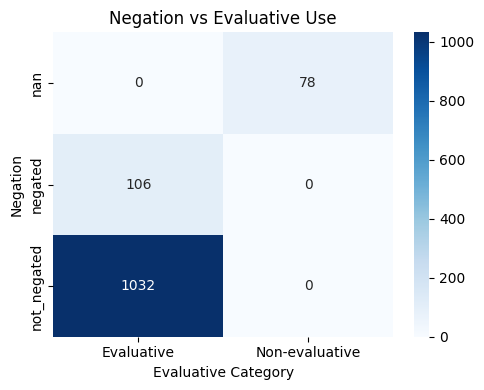

Negation vs. Attitude type:
DE_Attitude_type  Affect  Appreciation  Judgement
negation                                         
negated               13            50         42
not_negated           73           736        223
Chi2 = 25.12, df = 2, p = 0.0000


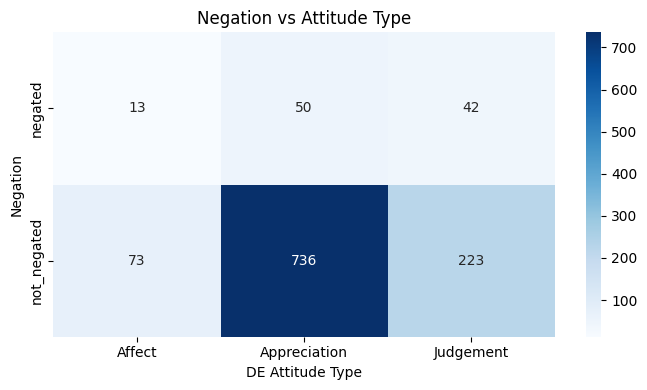

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ==============================
# 10.1 Negation vs Evaluative use
# ==============================

# Remove NaN
df_neg_eval = df.dropna(subset=["negation", "Evaluative_binary"])

neg_vs_eval = pd.crosstab(
    df_neg_eval["negation"],
    df_neg_eval["Evaluative_binary"]
)

print("Negation vs. Evaluative use:")
print(neg_vs_eval)

chi2, p, dof, expected = chi2_contingency(neg_vs_eval)
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}\n")


# Plot
plt.figure(figsize=(5, 4))
sns.heatmap(
    neg_vs_eval,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Negation vs Evaluative Use")
plt.xlabel("Evaluative Category")
plt.ylabel("Negation")
plt.tight_layout()
plt.show()


# ==============================
# 10.2 Negation vs Attitude type
# ==============================

# Remove NaN
df_neg_att = df_attitude.dropna(subset=["negation", "DE_Attitude_type"])

neg_vs_att = pd.crosstab(
    df_neg_att["negation"],
    df_neg_att["DE_Attitude_type"]
)

print("Negation vs. Attitude type:")
print(neg_vs_att)

chi2, p, dof, expected = chi2_contingency(neg_vs_att)
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")


# Plot
plt.figure(figsize=(7, 4))
sns.heatmap(
    neg_vs_att,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Negation vs Attitude Type")
plt.xlabel("DE Attitude Type")
plt.ylabel("Negation")
plt.tight_layout()
plt.show()

In [147]:

eval_domain = pd.crosstab(df["Domain"], df["Evaluative_binary"])
chi2, p, dof, expected = chi2_contingency(eval_domain)
print("Evaluative use by Domain:")
print(eval_domain)
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")


Evaluative use by Domain:
Evaluative_binary  Evaluative  Non-evaluative
Domain                                       
Art                       119               6
Business                  127               4
Education                 127               6
Entertainment             103              12
History                    78               5
Medicine                  110              11
Philosophy                130              10
Politics And Law           81               4
Psychology                103               8
Science                    67               8
Technology                 93               4
Chi2 = 12.13, df = 10, p = 0.2763


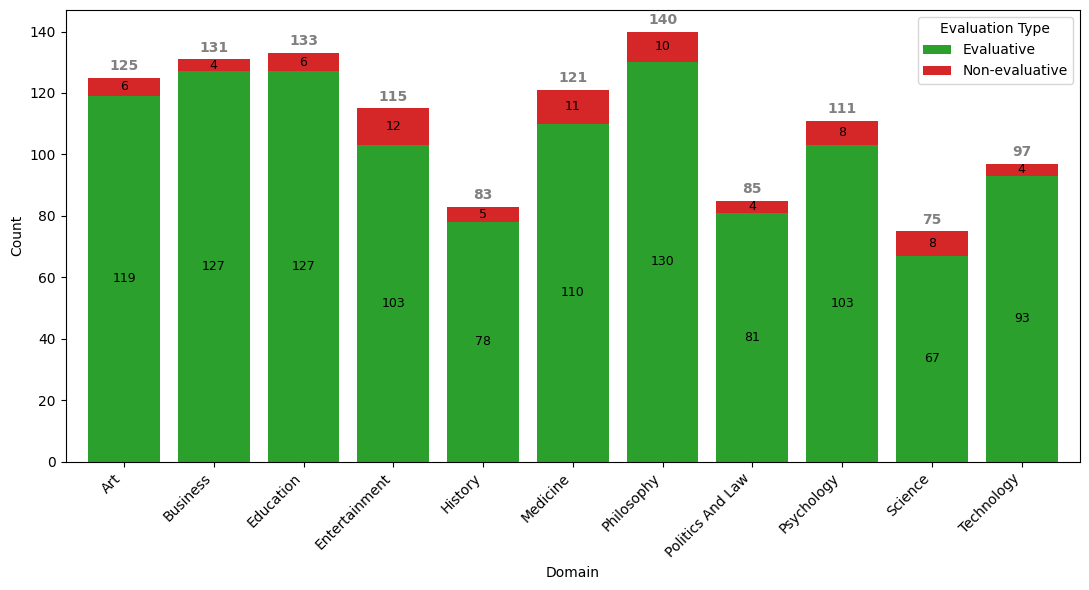

In [144]:
import matplotlib.pyplot as plt
import pandas as pd

# Counts table
eval_by_domain = pd.crosstab(
    df["Domain"],
    df["Evaluative_binary"]
)

# Reorder categories
order = ["Evaluative", "Non-evaluative"]
eval_by_domain = eval_by_domain.reindex(columns=order)

# Plot
ax = eval_by_domain.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    color=["tab:green", "tab:red"],
    width=0.8
)

# Labels inside each segment
for container in ax.containers:
    labels = [
        f"{int(v)}" if v > 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Total labels on top of each bar
totals = eval_by_domain.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 1.5,
        str(total),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="gray"
    )

# Formatting
plt.xlabel("Domain")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Evaluation Type")
plt.tight_layout()
plt.show()

Evaluative use by Gender:
Evaluative_binary  Evaluative  Non-evaluative
Gender                                       
F                         546              37
M                         592              41
Chi2 = 0.00, df = 1, p = 1.0000



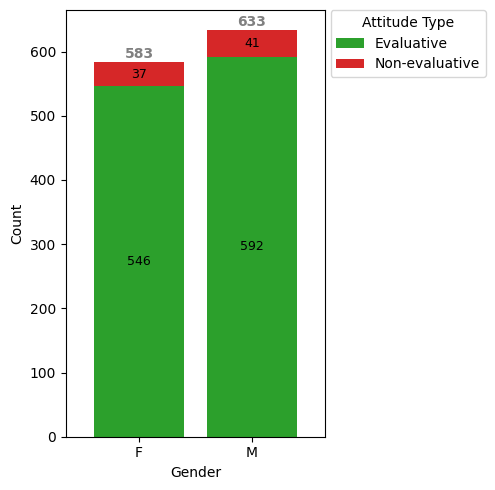

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ==============================
# 10.2 Evaluative use across Gender
# ==============================

df_gender = df.dropna(subset=["Gender", "Evaluative_binary"])

eval_gender = pd.crosstab(
    df_gender["Gender"],
    df_gender["Evaluative_binary"]
)

chi2, p, dof, expected = chi2_contingency(eval_gender)

print("Evaluative use by Gender:")
print(eval_gender)
print(f"Chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}\n")




# ==============================
# Evaluative use by Gender
# ==============================

eval_gender = pd.crosstab(
    df["Gender"],
    df["Evaluative_binary"]
)

# Reorder categories
order = ["Evaluative", "Non-evaluative"]
eval_gender = eval_gender.reindex(columns=order)

ax = eval_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 5),
    color=["tab:green", "tab:red"],
    width=0.8
)

# Labels inside segments
for container in ax.containers:
    labels = [
        f"{int(v)}" if v > 0 else ""
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

# Total labels
totals = eval_gender.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 2,
        str(total),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="gray"
    )

plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Evaluation Type")


plt.legend(
    title="Attitude Type",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [150]:
# 10.3 Attitude type by speaker's German variety (uses the merged metadata column)
att_by_variety = pd.crosstab(df_attitude["Speaker_variety"], df_attitude["DE_Attitude_type"])
print(att_by_variety)

chi2, p, dof, expected = chi2_contingency(att_by_variety)
print(f"\nChi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}")
print("Note: small group sizes for Austrian/Swiss speakers likely make this test unreliable "
      "- read the raw counts above alongside the p-value.")




DE_Attitude_type  Affect  Appreciation  Judgement
Speaker_variety                                  
Austrian               1            96         34
German                83           667        223
German (dialect)       0            15          4
Swiss                  2             8          4

Chi2 = 13.08, df = 6, p = 0.0418
Note: small group sizes for Austrian/Swiss speakers likely make this test unreliable - read the raw counts above alongside the p-value.
